In [1]:
# Necessary libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
df=pd.read_csv('/content/austo_automobile+%282%29+%281%29.csv.xls')
df

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [4]:
df.isna().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


In [5]:
# to check the unique values

for col in df.columns:
    print(f"{col} :")
    print(df[col].unique())
    print("-" * 40)

    #gender

Age :
[53 52 50 49 47 46 45 51 54 48 44 43 42 41 40 39 38 37 36 35 34 33 32 31
 30 29 28 27 26 25 24 23 22]
----------------------------------------
Gender :
['Male' 'Femal' 'Female' nan 'Femle']
----------------------------------------
Profession :
['Business' 'Salaried']
----------------------------------------
Marital_status :
['Married' 'Single']
----------------------------------------
Education :
['Post Graduate' 'Graduate']
----------------------------------------
No_of_Dependents :
[4 3 2 1 0]
----------------------------------------
Personal_loan :
['No' 'Yes']
----------------------------------------
House_loan :
['No' 'Yes']
----------------------------------------
Partner_working :
['Yes' 'No']
----------------------------------------
Salary :
[99300 95500 97300 72500 79700 79800 80900 79100 89400 83700 81600 81300
 77400 77600 74100 87600 86800 95100 92600 98400 72700 84600 88000 85400
 78000 87900 81900 88500 87700 98300 94900 91100 74500 81700 84700 82200
 79600 77700 72

In [6]:
df['Gender'].value_counts()

,count
Gender,
Male,1199
Female,327
Femal,1
Femle,1


In [7]:
# Replace incorrect values with 'Female'

df['Gender'] = df['Gender'].replace(['Femal', 'Femle'], 'Female')

In [8]:
# Fill NaN values with the mode of the Gender column

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [9]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [10]:
# Fill missing PartnerSalary using TotalSalary - Salary
df['Partner_salary'] = df['Partner_salary'].fillna(df['Total_salary'] - df['Salary'])

In [11]:

# df=df.drop('Total_salary',axis=1)
# df=df.drop(['Marital_status','Profession'],axis=1)
# df

In [12]:
# Verify if this is correct
df.isna().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


In [13]:
df.dtypes

,0
Age,int64
Gender,object
Profession,object
Marital_status,object
Education,object
No_of_Dependents,int64
Personal_loan,object
House_loan,object
Partner_working,object
Salary,int64


In [14]:
df

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,0.0,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,0.0,32200,24000,Hatchback


UNIVARIATE ANALYSIS

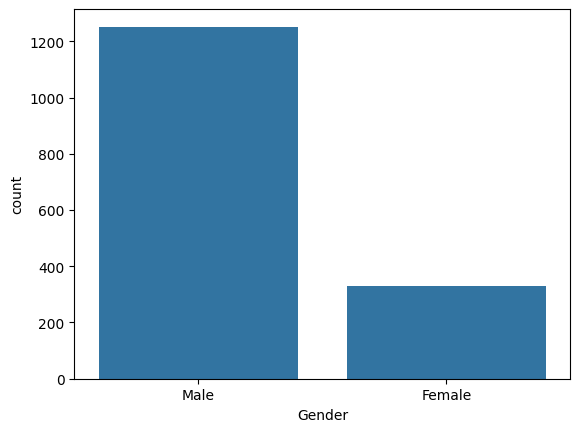

In [15]:
sns.countplot(x='Gender',data=df);

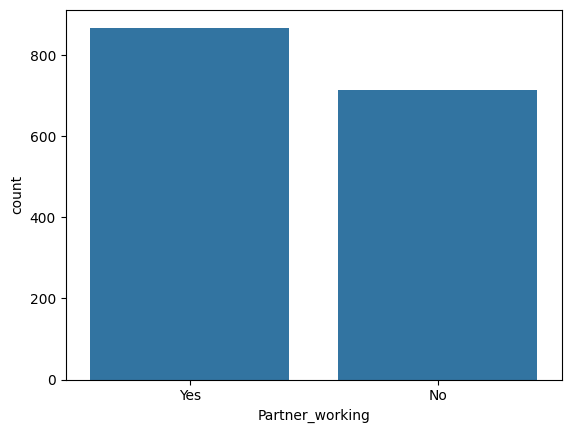

In [16]:
sns.countplot(x='Partner_working',data=df);

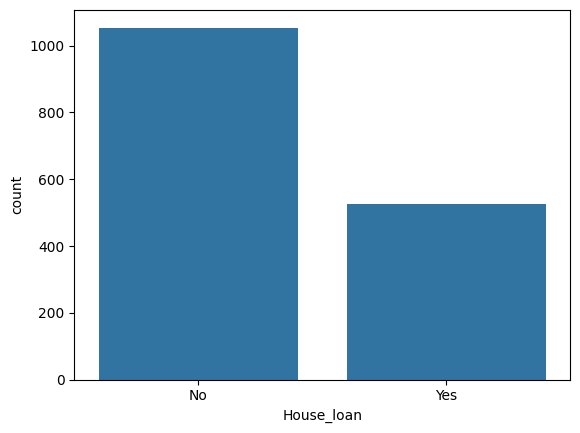

In [17]:
sns.countplot(x='House_loan',data=df);

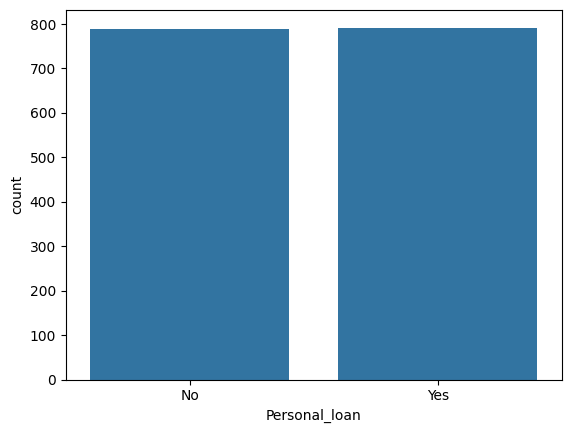

In [18]:
sns.countplot(x='Personal_loan',data=df);

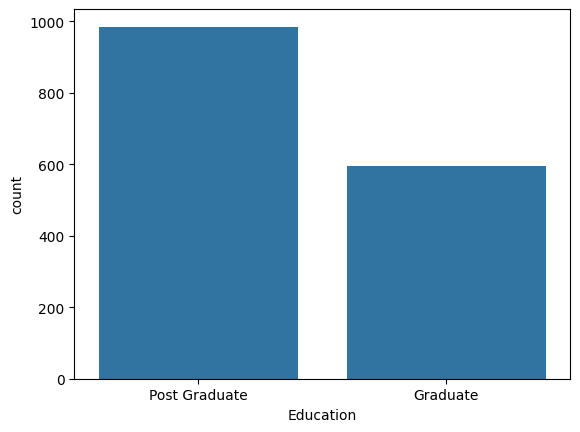

In [19]:
sns.countplot(x='Education',data=df);

BIVARIATE ANALYSIS

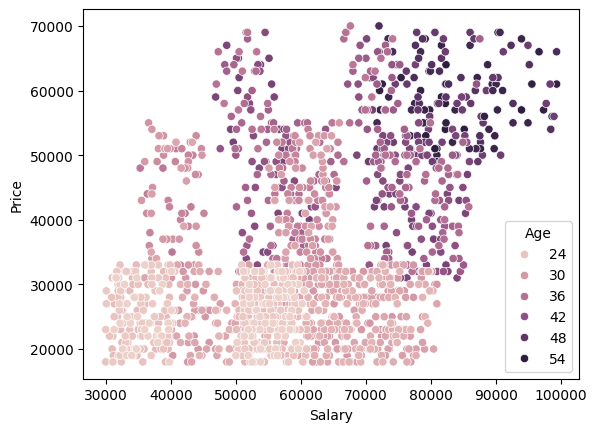

In [20]:
sns.scatterplot(x='Salary',y='Price',data=df,hue='Age');

MULTIVARIATE ANALYSIS

In [21]:
cat_col = df.select_dtypes(include='object').columns.to_list()
cat_col

['Gender',
 'Profession',
 'Marital_status',
 'Education',
 'Personal_loan',
 'House_loan',
 'Partner_working',
 'Make']

In [22]:
num_col = df.select_dtypes(exclude='object').columns.to_list()
num_col

['Age',
 'No_of_Dependents',
 'Salary',
 'Partner_salary',
 'Total_salary',
 'Price']

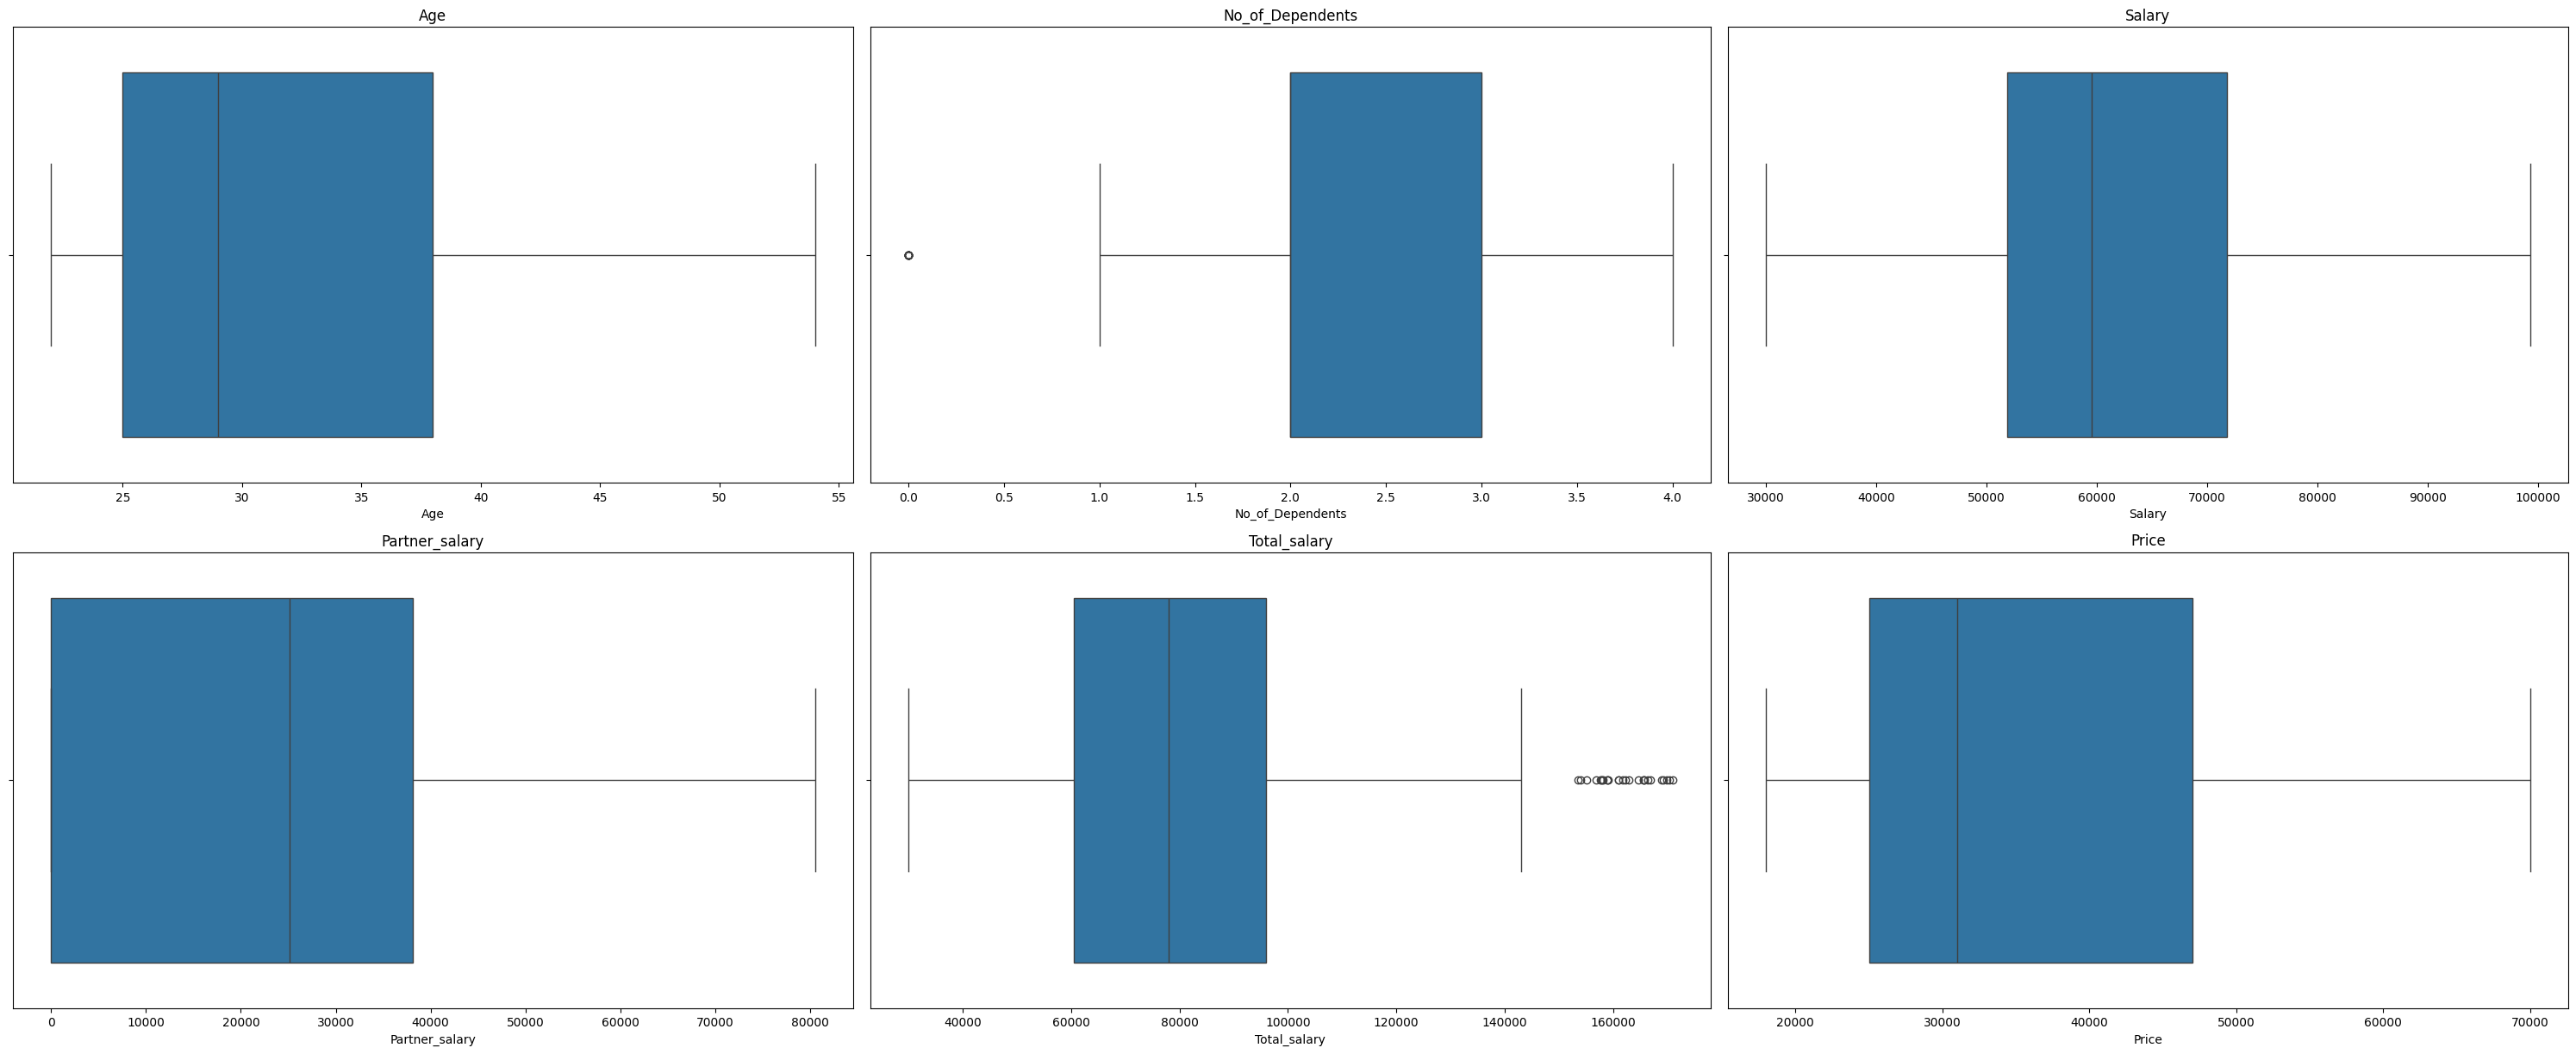

In [23]:
# checking outliers present or not
plt.figure(figsize=(30,18))

for i,col in enumerate(num_col):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

In [24]:
# Applied label encoding

from sklearn.preprocessing import LabelEncoder
# create dictionary to store encoders
label_encoders = {}

categorical_cols = df.select_dtypes(include='object').columns.to_list()

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store encoder
df

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,1,0,0,1,4,0,0,1,99300,70700.0,170000,61000,1
1,53,0,1,0,1,4,1,0,1,95500,70300.0,165800,61000,1
2,53,0,1,0,1,3,0,0,1,97300,60700.0,158000,57000,1
3,53,0,1,0,0,2,1,0,1,72500,70300.0,142800,61000,1
4,53,1,1,0,1,3,0,0,1,79700,60200.0,139900,57000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,22,1,1,1,0,2,0,1,0,33300,0.0,33300,27000,0
1577,22,1,0,0,0,4,0,0,0,32000,0.0,32000,31000,0
1578,22,1,0,1,0,2,0,1,0,32900,0.0,32900,30000,0
1579,22,1,0,0,0,3,1,1,0,32200,0.0,32200,24000,0


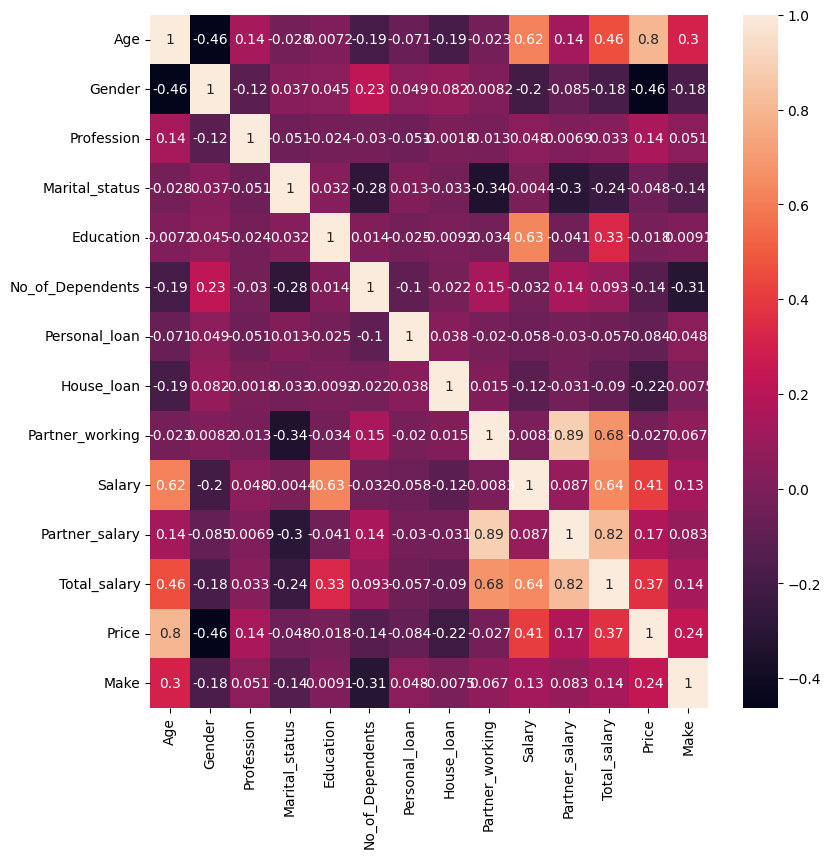

In [25]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr(),annot=True);

In [26]:
df=df.drop('Total_salary',axis=1)
df=df.drop(['Marital_status','Profession'],axis=1)
df

,Age,Gender,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Price,Make
0,53,1,1,4,0,0,1,99300,70700.0,61000,1
1,53,0,1,4,1,0,1,95500,70300.0,61000,1
2,53,0,1,3,0,0,1,97300,60700.0,57000,1
3,53,0,0,2,1,0,1,72500,70300.0,61000,1
4,53,1,1,3,0,0,1,79700,60200.0,57000,1
...,...,...,...,...,...,...,...,...,...,...,...
1576,22,1,0,2,0,1,0,33300,0.0,27000,0
1577,22,1,0,4,0,0,0,32000,0.0,31000,0
1578,22,1,0,2,0,1,0,32900,0.0,30000,0
1579,22,1,0,3,1,1,0,32200,0.0,24000,0


In [27]:
# Verify if this is correct
df.dtypes

,0
Age,int64
Gender,int64
Education,int64
No_of_Dependents,int64
Personal_loan,int64
House_loan,int64
Partner_working,int64
Salary,int64
Partner_salary,float64
Price,int64


In [28]:
x = df.drop(columns=['Make'])


In [29]:
y=df['Make']
y

,Make
0,1
1,1
2,1
3,1
4,1
...,...
1576,0
1577,0
1578,0
1579,0


In [30]:
df['Make'].value_counts()

#imbalanced

,count
Make,
2,702
0,582
1,297


In [31]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=1)
X_sm,y_sm = sm.fit_resample(x,y)

In [32]:
# scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
#scaler.fit(x)
X_scaled = scaler.fit_transform(x)

# X_scaled

In [33]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sm, y_sm, test_size=0.3, random_state=1
)

Model Creation

KNN


In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluation
print("**** KNN Classification Report ****")
print(classification_report(y_test, y_pred_knn))

print("**** KNN Confusion Matrix ****")
print(confusion_matrix(y_test, y_pred_knn))

**** KNN Classification Report ****
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       214
           1       0.85      0.90      0.87       204
           2       0.63      0.55      0.59       214

    accuracy                           0.74       632
   macro avg       0.73      0.74      0.74       632
weighted avg       0.73      0.74      0.73       632

**** KNN Confusion Matrix ****
[[167   0  47]
 [  0 183  21]
 [ 64  33 117]]


In [35]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
print(accuracy_score(y_test,y_pred_knn)*100)

73.89240506329115


Naive Bayes model

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

# Train model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict
y_pred_nb = nb.predict(X_test)

# Evaluation
print("**** Naive Bayes Classification Report ****")
print(classification_report(y_test, y_pred_nb))

print("**** Naive Bayes Confusion Matrix ****")
print(confusion_matrix(y_test, y_pred_nb))

**** Naive Bayes Classification Report ****
              precision    recall  f1-score   support

           0       0.70      0.97      0.81       214
           1       0.83      0.89      0.86       204
           2       0.76      0.43      0.55       214

    accuracy                           0.76       632
   macro avg       0.77      0.76      0.74       632
weighted avg       0.77      0.76      0.74       632

**** Naive Bayes Confusion Matrix ****
[[207   0   7]
 [  1 181  22]
 [ 86  36  92]]


In [37]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
print(nb.score(X_train,y_train)*100)

74.08412483039348


Decision Tree model

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train model
dt = DecisionTreeClassifier(random_state=1)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
print("**** Decision Tree Classification Report ****")
print(classification_report(y_test, y_pred_dt))

print("**** Decision Tree Confusion Matrix ****")
print(confusion_matrix(y_test, y_pred_dt))

**** Decision Tree Classification Report ****
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       214
           1       0.90      0.90      0.90       204
           2       0.73      0.73      0.73       214

    accuracy                           0.82       632
   macro avg       0.82      0.82      0.82       632
weighted avg       0.82      0.82      0.82       632

**** Decision Tree Confusion Matrix ****
[[178   0  36]
 [  0 183  21]
 [ 37  21 156]]


In [39]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
print(dt.score(X_train,y_train)*100)

100.0


Random Forest model

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train model
rf = RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
print("**** Random Forest Classification Report ****")
print(classification_report(y_test, y_pred_rf))

print("**** Random Forest Confusion Matrix ****")
print(confusion_matrix(y_test, y_pred_rf))

**** Random Forest Classification Report ****
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       214
           1       0.93      0.94      0.94       204
           2       0.81      0.71      0.75       214

    accuracy                           0.84       632
   macro avg       0.84      0.84      0.84       632
weighted avg       0.84      0.84      0.84       632

**** Random Forest Confusion Matrix ****
[[190   0  24]
 [  0 192  12]
 [ 49  14 151]]


In [41]:
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
print(accuracy_score(y_test,y_pred_rf)*100)

84.33544303797468


In [42]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report
from sklearn.svm import SVC

models = [
    AdaBoostClassifier(random_state=1),
    GradientBoostingClassifier(random_state=1),
    BaggingClassifier(),
    XGBClassifier(random_state=1),
    SVC()
]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n**** {model.__class__.__name__} ****")
    print(classification_report(y_test, y_pred))


    print(model.score(X_train,y_train)*100)


**** AdaBoostClassifier ****
              precision    recall  f1-score   support

           0       0.71      0.98      0.82       214
           1       0.85      0.79      0.82       204
           2       0.68      0.47      0.55       214

    accuracy                           0.75       632
   macro avg       0.75      0.75      0.73       632
weighted avg       0.75      0.75      0.73       632

72.59158751696066

**** GradientBoostingClassifier ****
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       214
           1       0.93      0.96      0.94       204
           2       0.83      0.74      0.78       214

    accuracy                           0.86       632
   macro avg       0.86      0.86      0.86       632
weighted avg       0.86      0.86      0.86       632

93.7584803256445

**** BaggingClassifier ****
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       2

In [43]:
Gb = GradientBoostingClassifier(random_state=1)
Gb.fit(X_train,y_train)
y_pred_gb = Gb.predict(X_test)
classification_report(y_test,y_pred_gb)
Gb.score(X_train,y_train)

print(Gb.score(X_train,y_train)*100)

93.7584803256445


## Gradient Boosting Classifier Model Tuning

In [44]:
param = {'loss': ['log_loss', 'exponential'],
          'verbose':[100,150],
    'learning_rate': [0.001,0.1],
    'n_estimators': [50,80],
    'max_depth': [ 5, 7],
         'random_state':[2,1]}

In [45]:
GCV = GridSearchCV(Gb,param,cv=3,scoring='accuracy')
GCV.fit(X_train,y_train)

Streaming output truncated to the last 5000 lines.
        76           1.0089            0.05s
        77           1.0079            0.04s
        78           1.0068            0.03s
        79           1.0057            0.01s
        80           1.0046            0.00s
      Iter       Train Loss   Remaining Time 
         1           1.0973            0.86s
         2           1.0961            0.87s
         3           1.0948            1.06s
         4           1.0935            1.03s
         5           1.0923            0.98s
         6           1.0910            0.96s
         7           1.0898            0.95s
         8           1.0885            0.93s
         9           1.0873            0.91s
        10           1.0860            0.90s
        11           1.0848            0.89s
        12           1.0835            0.87s
        13           1.0823            0.86s
        14           1.0811            0.84s
        15           1.0798            0.83s
   

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=1),
             param_grid={'learning_rate': [0.001, 0.1],
                         'loss': ['log_loss', 'exponential'],
                         'max_depth': [5, 7], 'n_estimators': [50, 80],
                         'random_state': [2, 1], 'verbose': [100, 150]},
             scoring='accuracy')

In [46]:
GCV.best_params_

{'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 7,
 'n_estimators': 80,
 'random_state': 1,
 'verbose': 100}

In [47]:
y_pred_GCV = GCV.predict(X_test)

In [48]:
print(classification_report(y_test,y_pred_GCV))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       214
           1       0.95      0.94      0.95       204
           2       0.80      0.78      0.79       214

    accuracy                           0.86       632
   macro avg       0.86      0.86      0.86       632
weighted avg       0.86      0.86      0.86       632



In [49]:
GCV.score(X_train,y_train)

1.0

In [50]:
import pickle
pickle.dump(Gb,open('model_gb_auto.sav_new1','wb'))
pickle.dump(scaler,open('scaler_automobile.sav_new1','wb'))
pickle.dump(le,open('Encoded_automobile.sav_new1','wb'))